In [1]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
from kafka import KafkaConsumer, TopicPartition
import json
import numpy as np
import time
import matplotlib.mlab as mlab
from baskervillehall.baskervillehall_isolation_forest import ModelType
import pandas as pd
from sklearn.preprocessing import StandardScaler
from baskervillehall.baskervillehall_isolation_forest import BaskervillehallIsolationForest
from baskervillehall.baskervillehall_isolation_forest import ModelType

2025-11-11 11:21:50.146759: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762860110.265562      82 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762860110.301598      82 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762860110.572585      82 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762860110.572642      82 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762860110.572645      82 computation_placer.cc:177] computation placer alr

In [3]:
import logging
import sys
logger = logging.getLogger('ai')
logger.addHandler(logging.StreamHandler())
logger.addHandler(logging.StreamHandler(sys.stdout))
logger.setLevel('DEBUG')

In [4]:
kafka_url = ['kafka9-0.kafka9-headless.default.svc.cluster.local:9093','kafka9-1.kafka9-headless.default.svc.cluster.local:9093','kafka9-2.kafka9-headless.default.svc.cluster.local:9093']
partitions = {
    'vytoki.net': 0,
    'zhitomir.info': 1,
    'urban-pushkino.ru': 0,
    'dev.emawpb.org': 0,
    'palestinechronicle.com': 1,
    'equalit.ie': 0,
    'lexota.org': 0,
    'kavkaz-uzel.eu': 0,
    'amp.kavkaz-uzel.eu': 2,
    'indymedia.nl': 0,
    'btselem.org': 0,
    'verafiles.org': 1,
    'telegraf.in.ua': 2,
    'gubernia.com': 1,
    'informator.ua': 0,
    'culturesofresistance.org': 2,
    'zmina.info': 1,
    'memex.craphound.com': 2,
    'greencubator.info': 0
}
datetime_format = '%Y-%m-%d %H:%M:%S'
topic = 'BASKERVILLEHALL_4'

In [5]:
features = [
            'request_rate', 'post_rate', 'request_interval_average',
            'request_interval_std', 'response4xx_to_request_ratio',
            'response5xx_to_request_ratio', 'top_page_to_request_ratio',
            'unique_path_rate', 'unique_path_to_request_ratio',
            'unique_query_rate', 'unique_query_to_unique_path_ratio',
            'image_to_html_ratio', 'js_to_html_ratio', 'css_to_html_ratio',
            'path_depth_average', 'path_depth_std', 'payload_size_log_average',
            'entropy', 'num_requests', 'duration', 'edge_count', 'static_ratio',
            'ua_count', 'api_ratio', 'num_ciphers', 'num_languages',
            'ua_score', 'hour_bucket', 'odd_hour', 'fingerprints_score',
            # 'interval_cv', 'interval_consistency',
            # 'rate_499'
]
categorical_features=[
            # 'country', 
            # 'primary_session', 
            # 'bad_bot', 
            # 'human', 
            'cipher',
            'valid_browser_ciphers', 
            'weak_cipher', 
            'headless_ua', 
            'bot_ua',
            'ai_bot_ua', 
            'verified_bot', 
            'datacenter_asn', 
            'short_ua'
]

In [6]:
def read_sessions_with_labels(size=1000):
    from kafka import KafkaConsumer, TopicPartition
    import json
    import time

    consumer = KafkaConsumer(bootstrap_servers=kafka_url)
    
    num = 0
    
    print(f'Reading from kafka.')
    time_now = int(time.time())
    sessions = []
    labels = []

    consumer.assign([TopicPartition(topic, p) for p in range(9)])
    consumer.seek_to_beginning()
    complete = False

    while not complete:
        raw_messages = consumer.poll(timeout_ms=1000, max_records=100)

        for topic_partition, messages in raw_messages.items():
            for message in messages:
                # prevent from getting messages too close to the current time
                time_diff_in_minutes = (time_now - message.timestamp / 1000) / 60
                if time_diff_in_minutes < 2:
                    print(f'{time_diff_in_minutes:.2f} minutes. Topic offset is too close to the current time...')
                    complete = True
                    break
                
                if message.value is None or message.key is None:
                    continue

                s = json.loads(message.value.decode("utf-8"))  

                if s['asset_only']:
                    continue
                if s['primary_session']:
                    continue
                human = s.get('human', False)
                if not human:
                    continue

                if s['passed_challenge']:
                    if s['bot_score'] > 0.2 and s['bot_score_top_factor'] != 'no_payload' \
                          and s['bot_score_top_factor'] != 'err_payload':
                        label = 1
                    else:
                        label = 0
                else:
                    label = 1

                if len(sessions) == 0:
                    print(f'First session start = {s["start"]} end = {s["end"]}')

                sessions.append(s)
                labels.append(label)

                if num == size:
                    complete = True
                    break

                num += 1
                if num % 10000 == 0:
                    print(f'{num} sessions read', s['end'], message.timestamp)

    return sessions, labels


In [21]:
sessions, labels = read_sessions_with_labels(size=20000)

Reading from kafka.
First session start = 2025-10-29 18:21:00 end = 2025-10-29 18:21:08
10000 sessions read 2025-10-30 22:01:56 1762059424265
20000 sessions read 2025-10-30 22:04:49 1762083739283


In [22]:
y = np.array(labels)
print(f'humans = {len(y[y==0])}, bots = {len(y[y==1])}')

humans = 3707, bots = 16294


In [23]:
num_smart_bots = 0
for s in sessions:
    if s['bot_score'] > 0.2 and s['bot_score_top_factor'] != 'no_payload' \
      and s['bot_score_top_factor'] != 'err_payload':
        num_smart_bots += 1
        # print('\n@@@@@@@@@@@@@@@@@@@@@@')
        # print(s['host'], s['bot_score'], s['bot_score_top_factor'], s['passed_challenge'])
        # for r in s['requests']:
        #     print(r['ts'], r['url'])
        # break
print(f'num_smart_bots = {num_smart_bots}')

num_smart_bots = 242


In [24]:
from baskervillehall.feature_extractor import FeatureExtractor
fe = FeatureExtractor(features=features, categorical_features=categorical_features)
X = fe.fit_transform(sessions)

In [25]:
# Разделим на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

[0]	train-aucpr:0.95982+0.00142	test-aucpr:0.95406+0.00208
[1]	train-aucpr:0.97025+0.00070	test-aucpr:0.96542+0.00432
[2]	train-aucpr:0.97807+0.00140	test-aucpr:0.97426+0.00216
[3]	train-aucpr:0.98082+0.00185	test-aucpr:0.97753+0.00203
[4]	train-aucpr:0.98206+0.00143	test-aucpr:0.97894+0.00208
[5]	train-aucpr:0.98273+0.00150	test-aucpr:0.97949+0.00205
[6]	train-aucpr:0.98366+0.00078	test-aucpr:0.98055+0.00146
[7]	train-aucpr:0.98359+0.00078	test-aucpr:0.98037+0.00174
[8]	train-aucpr:0.98410+0.00118	test-aucpr:0.98100+0.00245
[9]	train-aucpr:0.98440+0.00094	test-aucpr:0.98126+0.00218
[10]	train-aucpr:0.98487+0.00102	test-aucpr:0.98173+0.00202
[11]	train-aucpr:0.98487+0.00089	test-aucpr:0.98183+0.00199
[12]	train-aucpr:0.98468+0.00082	test-aucpr:0.98162+0.00211
[13]	train-aucpr:0.98535+0.00098	test-aucpr:0.98240+0.00180
[14]	train-aucpr:0.98549+0.00097	test-aucpr:0.98265+0.00172
[15]	train-aucpr:0.98572+0.00089	test-aucpr:0.98279+0.00164
[16]	train-aucpr:0.98591+0.00081	test-aucpr:0.9830

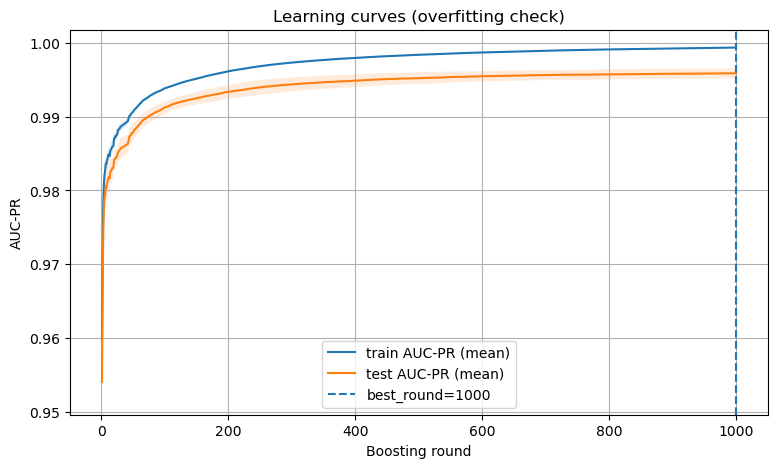

AUC-PR (test): 0.99651
Best threshold by F1: 0.310 | F1=0.973

Classification report @ best threshold:
              precision    recall  f1-score   support

           0      0.867     0.903     0.885      1477
           1      0.978     0.969     0.973      6524

    accuracy                          0.957      8001
   macro avg      0.923     0.936     0.929      8001
weighted avg      0.957     0.957     0.957      8001



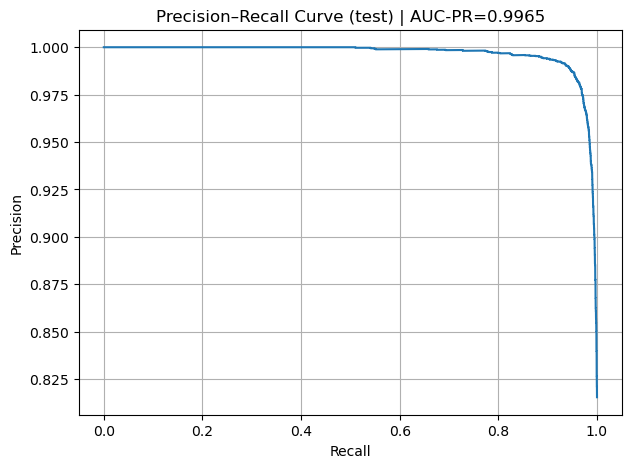

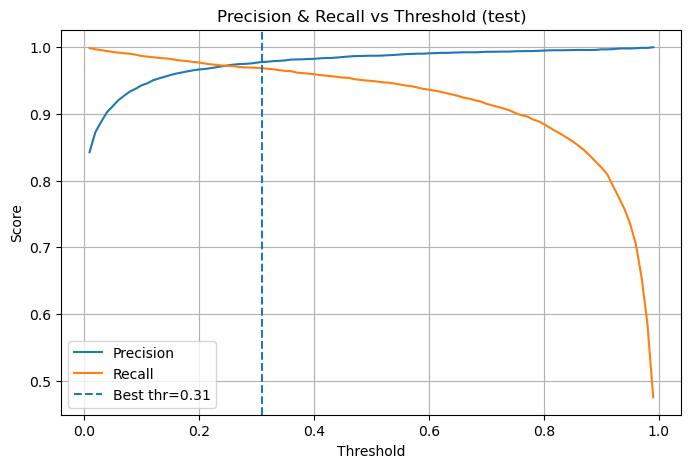

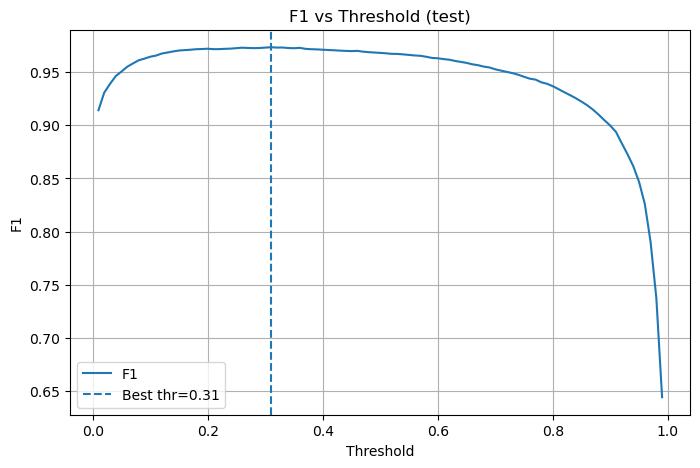

In [30]:
# --- imports ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    precision_score, recall_score, f1_score, classification_report
)
import xgboost as xgb

# ===== 0) Базовые параметры =====
# важное: считаем веса дисбаланса по train, не по всей выборке
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = neg / max(1, pos)

cv_params = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "tree_method": "hist",
    "learning_rate": 0.03,
    "max_depth": 6,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "gamma": 0.1,
    "lambda": 1.0,
    "alpha": 0.0,
    "scale_pos_weight": scale_pos_weight * 0.7,
    "max_delta_step": 1,
    # n_estimators/num_boost_round зададим ниже
}

# ===== 1) CV с кривыми обучения (overfitting check) =====
dtrain = xgb.DMatrix(X_train, label=y_train)

cv = xgb.cv(
    params=cv_params,
    dtrain=dtrain,
    num_boost_round=1000,         # большой верхний предел
    nfold=5,
    stratified=True,
    metrics=('aucpr',),
    early_stopping_rounds=100,    # авто-стоп
    verbose_eval=True,
    seed=42
)

best_round = cv.shape[0]   # лучшая итерация по CV
print(f"Best num_boost_round (CV): {best_round}")

# --- рисуем train vs test AUC-PR (mean ± std) ---
x = np.arange(1, best_round + 1)
train_mean = cv['train-aucpr-mean'].values
test_mean  = cv['test-aucpr-mean'].values
train_std  = cv['train-aucpr-std'].values
test_std   = cv['test-aucpr-std'].values

plt.figure(figsize=(9,5))
plt.plot(x, train_mean, label='train AUC-PR (mean)')
plt.fill_between(x, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.plot(x, test_mean,  label='test AUC-PR (mean)')
plt.fill_between(x, test_mean - test_std, test_mean + test_std, alpha=0.15)
plt.axvline(best_round, linestyle='--', label=f'best_round={best_round}')
plt.xlabel('Boosting round')
plt.ylabel('AUC-PR')
plt.title('Learning curves (overfitting check)')
plt.legend()
plt.grid(True)
plt.show()

# ===== 2) Обучаем финальную модель на всём train с best_round =====
# Можно через xgb.train или XGBClassifier — возьмём xgb.train для точного контроля итераций
final_model = xgb.train(
    params=cv_params,
    dtrain=dtrain,
    num_boost_round=best_round
)

# ===== 3) Оценка на тесте + подбор порога =====
dtest = xgb.DMatrix(X_test)
y_proba = final_model.predict(dtest)

# AUC-PR на тесте
aucpr_test = average_precision_score(y_test, y_proba)
print(f"AUC-PR (test): {aucpr_test:.5f}")

# Поиск оптимального порога по F1
thresholds = np.linspace(0.01, 0.99, 99)
f1s = [f1_score(y_test, (y_proba > t).astype(int), zero_division=0) for t in thresholds]
best_idx = int(np.argmax(f1s))
best_t = thresholds[best_idx]
best_f1 = f1s[best_idx]
print(f"Best threshold by F1: {best_t:.3f} | F1={best_f1:.3f}")

# Полный отчёт @ лучшем пороге
y_pred_best = (y_proba > best_t).astype(int)
print("\nClassification report @ best threshold:")
print(classification_report(y_test, y_pred_best, digits=3))

# ===== 4) Визуализации качества =====
# PR-кривая
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision–Recall Curve (test) | AUC-PR={aucpr_test:.4f}')
plt.grid(True)
plt.show()

# Precision & Recall vs Threshold
precisions = [precision_score(y_test, (y_proba > t).astype(int), zero_division=0) for t in thresholds]
recalls    = [recall_score(y_test, (y_proba > t).astype(int), zero_division=0)    for t in thresholds]

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls,    label='Recall')
plt.axvline(best_t, linestyle='--', label=f'Best thr={best_t:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs Threshold (test)')
plt.legend()
plt.grid(True)
plt.show()

# F1 vs Threshold
plt.figure(figsize=(8,5))
plt.plot(thresholds, f1s, label='F1')
plt.axvline(best_t, linestyle='--', label=f'Best thr={best_t:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1')
plt.title('F1 vs Threshold (test)')
plt.legend()
plt.grid(True)
plt.show()


scale_pos_weight: 0.2623646141028554
Best threshold by F1: 0.210 | F1=0.975
AUC-PR: 0.9969


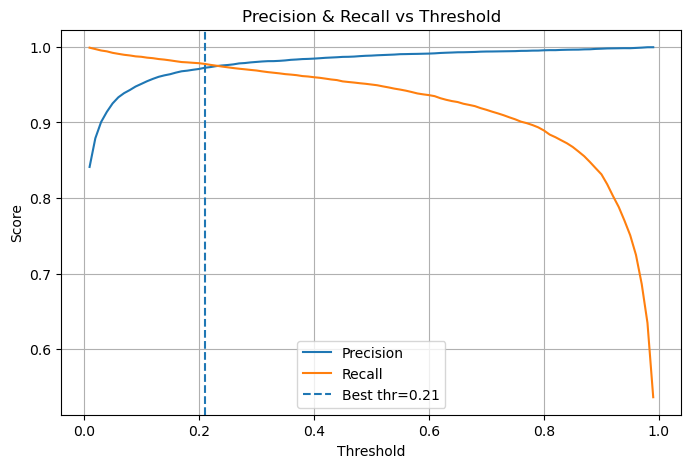

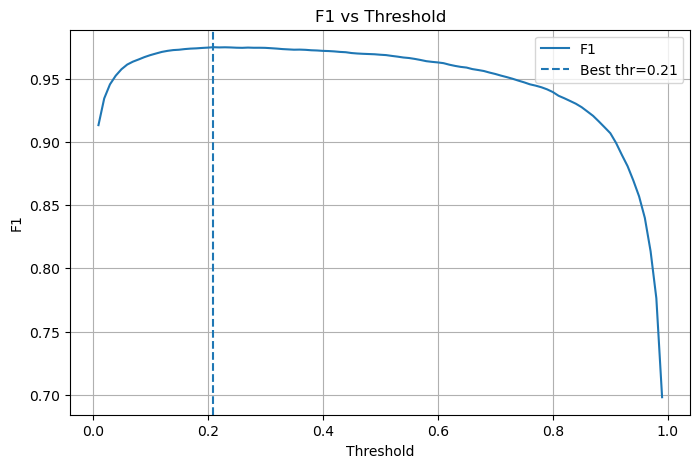


Classification report @ best threshold:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      4170
           1       0.97      0.98      0.97     15831

    accuracy                           0.96     20001
   macro avg       0.94      0.94      0.94     20001
weighted avg       0.96      0.96      0.96     20001



In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score, classification_report

# --- твой код обучения ---
scale_pos_weight = len(y[y==0]) / len(y[y==1])
print("scale_pos_weight:", scale_pos_weight)

params = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "tree_method": "hist",
    "learning_rate": 0.05,
    "max_depth": 6,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "gamma": 0.1,
    "lambda": 1.0,
    "alpha": 0.0,
    "n_estimators": 800,
    "scale_pos_weight": scale_pos_weight * 0.7,
    "max_delta_step": 1,
}

model = xgb.XGBClassifier(**params)
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, average_precision_score

# y_test: массив из {0,1}
# y_proba: вероятности класса 1 из model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)

precisions, recalls, f1s = [], [], []
for t in thresholds:
    y_pred_t = (y_proba > t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

precisions = np.array(precisions)
recalls = np.array(recalls)
f1s = np.array(f1s)

best_idx = np.argmax(f1s)
best_t = thresholds[best_idx]
best_f1 = f1s[best_idx]

print(f"Best threshold by F1: {best_t:.3f} | F1={best_f1:.3f}")
print(f"AUC-PR: {average_precision_score(y_test, y_proba):.4f}")

# Precision-Recall Curve
plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

# --- Precision & Recall vs Threshold ---
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.axvline(best_t, linestyle='--', label=f'Best thr={best_t:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

# --- F1 vs Threshold ---
plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1s, label='F1')
plt.axvline(best_t, linestyle='--', label=f'Best thr={best_t:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1')
plt.title('F1 vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

# --- Отчёт по лучшему порогу ---
y_pred_best = (y_proba > best_t).astype(int)
print("\nClassification report @ best threshold:")
print(classification_report(y_test, y_pred_best))


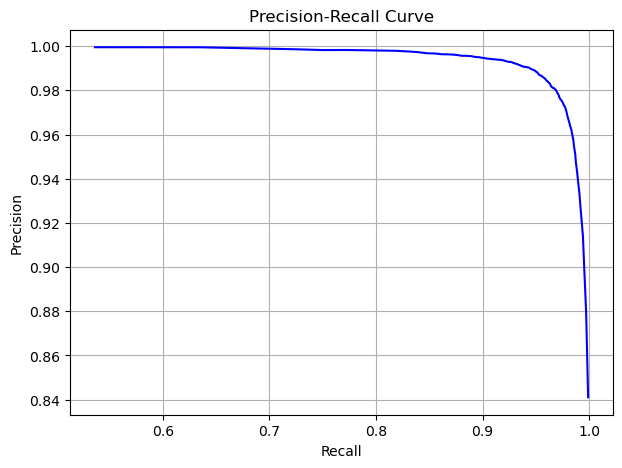

In [19]:
# Precision-Recall Curve
plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

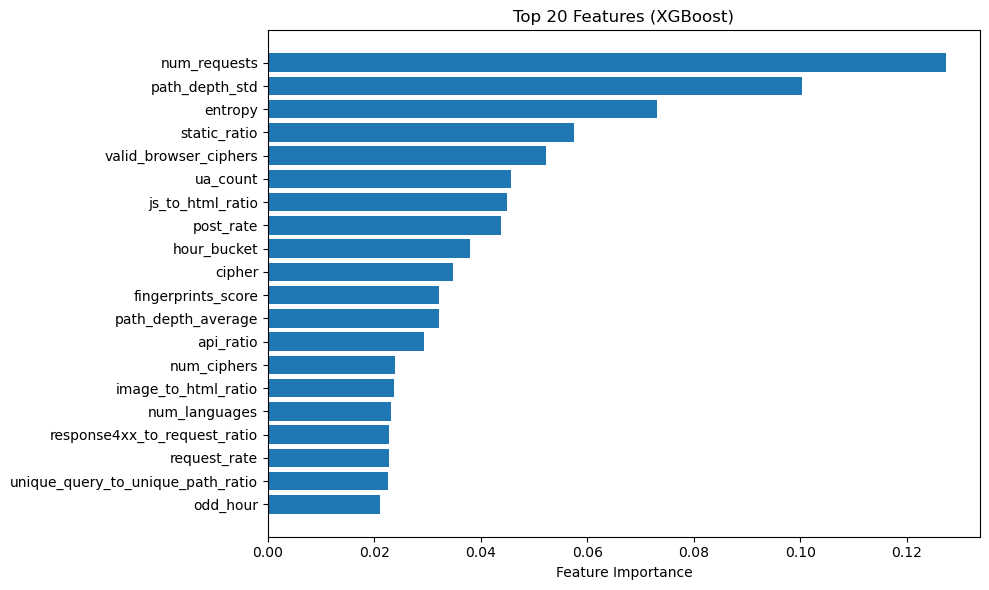

In [16]:
import matplotlib.pyplot as plt

# Имена признаков
feature_names = fe.get_all_features()

# Важность признаков
importances = model.feature_importances_

# Отсортируем
sorted_idx = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]

# Визуализация
plt.figure(figsize=(10, 6))
plt.barh(sorted_features[:20][::-1], importances[sorted_idx][:20][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Features (XGBoost)")
plt.tight_layout()
plt.show()


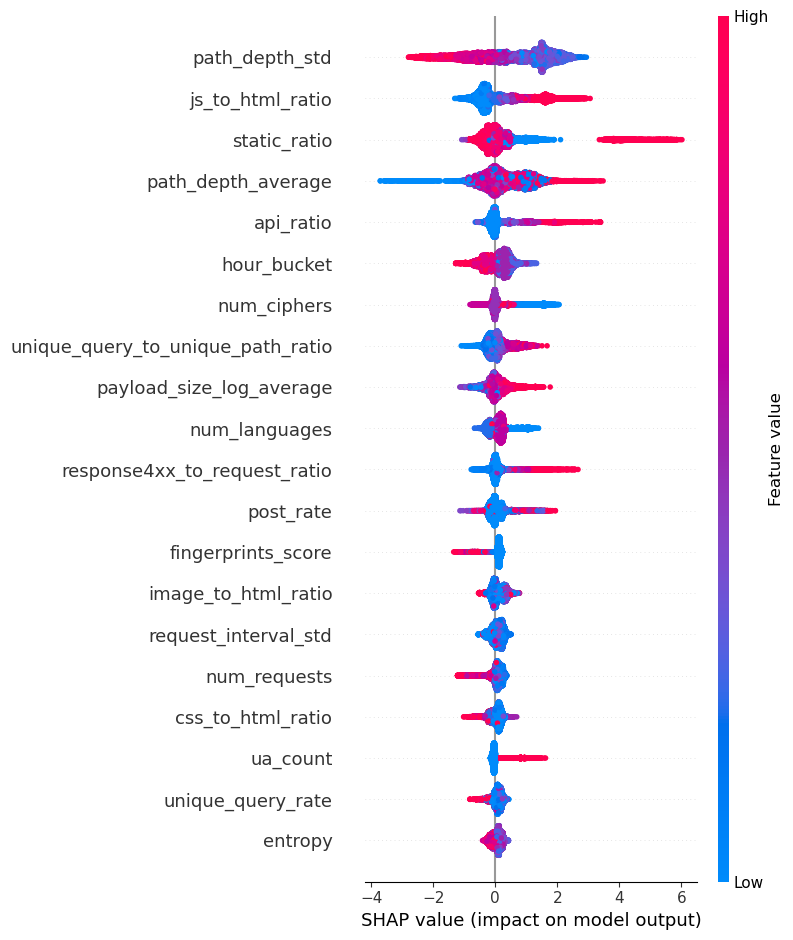

In [17]:
import shap

# Важно! Используем только XGBoost Booster
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Визуализируем
shap.summary_plot(shap_values, X_test, feature_names=feature_names)
